# M4-01: ML Fundamentals & Feature Engineering

This notebook covers the full pre-modeling workflow on the classic Titanic dataset:
- **Task 1** – Data Exploration (EDA)
- **Task 2** – Feature Engineering
- **Task 3** – Feature Scaling & Selection
- **Task 4** – Dimensionality Reduction (PCA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA

sns.set_style("whitegrid")

---
## Task 1: Data Exploration

In [2]:
titanic = sns.load_dataset("titanic")
print("Shape:", titanic.shape)
titanic.head()

Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# Data types
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB


In [4]:
# Missing values — count and percentage
missing = titanic.isnull().sum()
missing_pct = (missing / len(titanic) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})[missing > 0]

,missing_count,missing_%
age,177,19.87
embarked,2,0.22
deck,688,77.22
embark_town,2,0.22


In [5]:
# Class balance of target variable
print("Survival rate (%):", round(titanic['survived'].mean() * 100, 2))
titanic['survived'].value_counts(normalize=True)

Survival rate (%): 38.38


survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

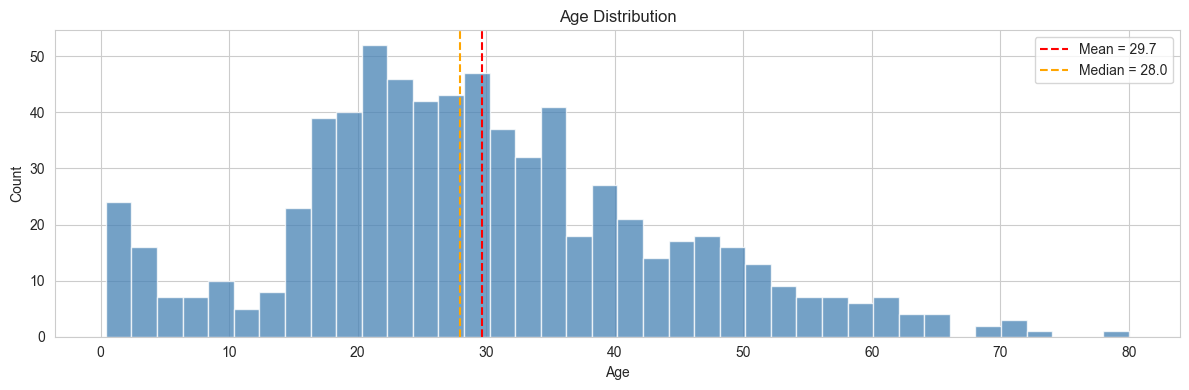

In [6]:
# Visualization 1: Distribution of Age
fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(titanic['age'].dropna(), bins=40, edgecolor='white', alpha=0.75, color='steelblue')
ax.axvline(titanic['age'].mean(), color='red', linestyle='--', label=f"Mean = {titanic['age'].mean():.1f}")
ax.axvline(titanic['age'].median(), color='orange', linestyle='--', label=f"Median = {titanic['age'].median():.1f}")
ax.set_title('Age Distribution')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

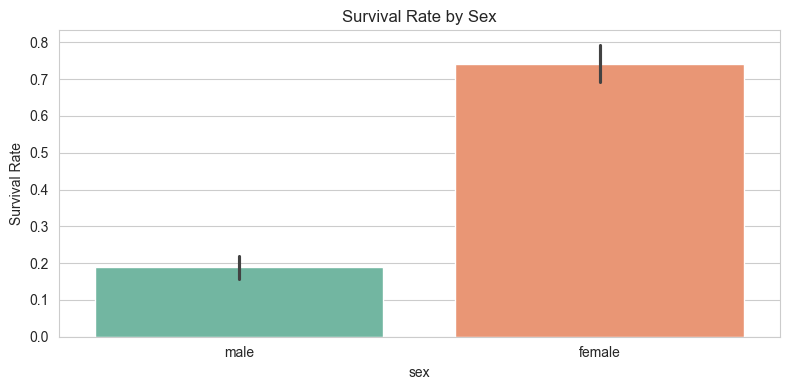

In [7]:
# Visualization 2: Survival rate by Sex
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=titanic, x='sex', y='survived', hue='sex', palette='Set2', ax=ax)
ax.set_title('Survival Rate by Sex')
ax.set_ylabel('Survival Rate')
plt.tight_layout()
plt.show()

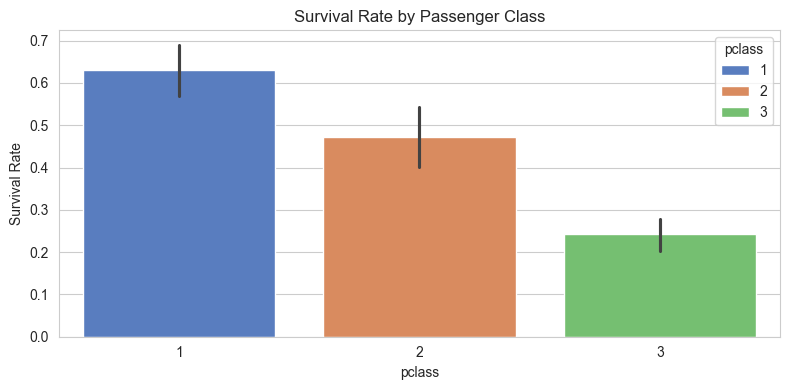

In [8]:
# Visualization 3: Survival rate by Passenger Class
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=titanic, x='pclass', y='survived', hue='pclass', palette='muted', ax=ax)
ax.set_title('Survival Rate by Passenger Class')
ax.set_ylabel('Survival Rate')
plt.tight_layout()
plt.show()

### Task 1 – Summary

- The dataset has **891 rows × 15 columns**.
- **Numerical columns**: `survived`, `pclass`, `age`, `sibsp`, `parch`, `fare`.
- **Categorical columns**: `sex`, `embarked`, `class`, `who`, `adult_male`, `deck`, `embark_town`, `alive`, `alone`.
- **Missing values**: `age` (~20%), `deck` (~77%), `embarked` (0.2%). `deck` is heavily missing and will be dropped.
- **Class balance**: ~38% survivors, ~62% non-survivors — a moderate class imbalance.
- **Key observations**:
  - Women survived at a much higher rate (~74%) than men (~19%) — the "women and children first" principle.
  - 1st-class passengers had the highest survival rate, 3rd-class the lowest.
  - Age is roughly right-skewed with the majority of passengers between 20–40 years old.

---
## Task 2: Feature Engineering

In [9]:
# Reload clean copy
titanic = sns.load_dataset("titanic")

# 2.1 Handle missing values
titanic['age'] = titanic['age'].fillna(titanic['age'].median())
titanic['embarked'] = titanic['embarked'].fillna(titanic['embarked'].mode()[0])
titanic = titanic.drop('deck', axis=1)

print("Remaining nulls:")
print(titanic.isnull().sum()[titanic.isnull().sum() > 0])

Remaining nulls:
embark_town    2
dtype: int64


In [10]:
# 2.2 Encode categorical features
# Label encode 'sex': female=0, male=1
le = LabelEncoder()
titanic['sex'] = le.fit_transform(titanic['sex'])
print("sex encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

# One-hot encode 'embarked' (drop first to avoid dummy trap)
titanic = pd.get_dummies(titanic, columns=['embarked'], drop_first=True)
print("Columns after OHE:", list(titanic.columns))

sex encoding: {'female': np.int64(0), 'male': np.int64(1)}
Columns after OHE: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone', 'embarked_Q', 'embarked_S']


In [11]:
# 2.3 Create new features
titanic['family_size'] = titanic['sibsp'] + titanic['parch'] + 1
titanic['is_alone'] = (titanic['family_size'] == 1).astype(int)

titanic[['sibsp', 'parch', 'family_size', 'is_alone']].head(10)

,sibsp,parch,family_size,is_alone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1
5,0,0,1,1
6,0,0,1,1
7,3,1,5,0
8,0,2,3,0
9,1,0,2,0


In [12]:
# 2.4 Drop non-numeric / identifier columns
cols_to_drop = ['alive', 'who', 'adult_male', 'embark_town', 'class', 'alone']
titanic = titanic.drop(columns=cols_to_drop)

print("Final columns:", list(titanic.columns))
print("All numeric:", titanic.select_dtypes(include=[np.number]).shape[1] == titanic.shape[1])
titanic.head()

Final columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked_Q', 'embarked_S', 'family_size', 'is_alone']
All numeric: False


,survived,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S,family_size,is_alone
0,0,3,1,22.0,1,0,7.2500,False,True,2,0
1,1,1,0,38.0,1,0,71.2833,False,False,2,0
2,1,3,0,26.0,0,0,7.9250,False,True,1,1
3,1,1,0,35.0,1,0,53.1000,False,True,2,0
4,0,3,1,35.0,0,0,8.0500,False,True,1,1


In [13]:
# Confirm all columns are numeric
titanic.dtypes

survived         int64
pclass           int64
sex              int64
age            float64
sibsp            int64
parch            int64
fare           float64
embarked_Q        bool
embarked_S        bool
family_size      int64
is_alone         int64
dtype: object

### Task 2 – Summary

- **Missing values**: `age` filled with median (28.0); `embarked` filled with mode ('S'); `deck` dropped (77% missing).
- **Encoding**: `sex` label-encoded (female=0, male=1); `embarked` one-hot encoded with `drop_first=True` to avoid multicollinearity.
- **New features**: `family_size = sibsp + parch + 1` captures total family aboard; `is_alone` is a binary flag.
- **Dropped columns**: `alive`, `who`, `adult_male`, `embark_town`, `class`, `alone` — either redundant, leaky, or non-numeric.
- The final DataFrame contains only numeric columns, ready for ML.

---
## Task 3: Feature Scaling & Selection

In [14]:
# Separate target and features
X = titanic.drop('survived', axis=1)
y = titanic['survived']

# 3.1 Apply StandardScaler and MinMaxScaler
scaler_std = StandardScaler()
scaler_mm  = MinMaxScaler()

X_std = pd.DataFrame(scaler_std.fit_transform(X), columns=X.columns)
X_mm  = pd.DataFrame(scaler_mm.fit_transform(X),  columns=X.columns)

print("StandardScaler — age stats:")
print(X_std['age'].describe().round(3))
print("\nMinMaxScaler — age stats:")
print(X_mm['age'].describe().round(3))

StandardScaler — age stats:
count    891.000
mean       0.000
std        1.001
min       -2.224
25%       -0.566
50%       -0.105
75%        0.433
max        3.892
Name: age, dtype: float64

MinMaxScaler — age stats:
count    891.000
mean       0.364
std        0.164
min        0.000
25%        0.271
50%        0.347
75%        0.435
max        1.000
Name: age, dtype: float64


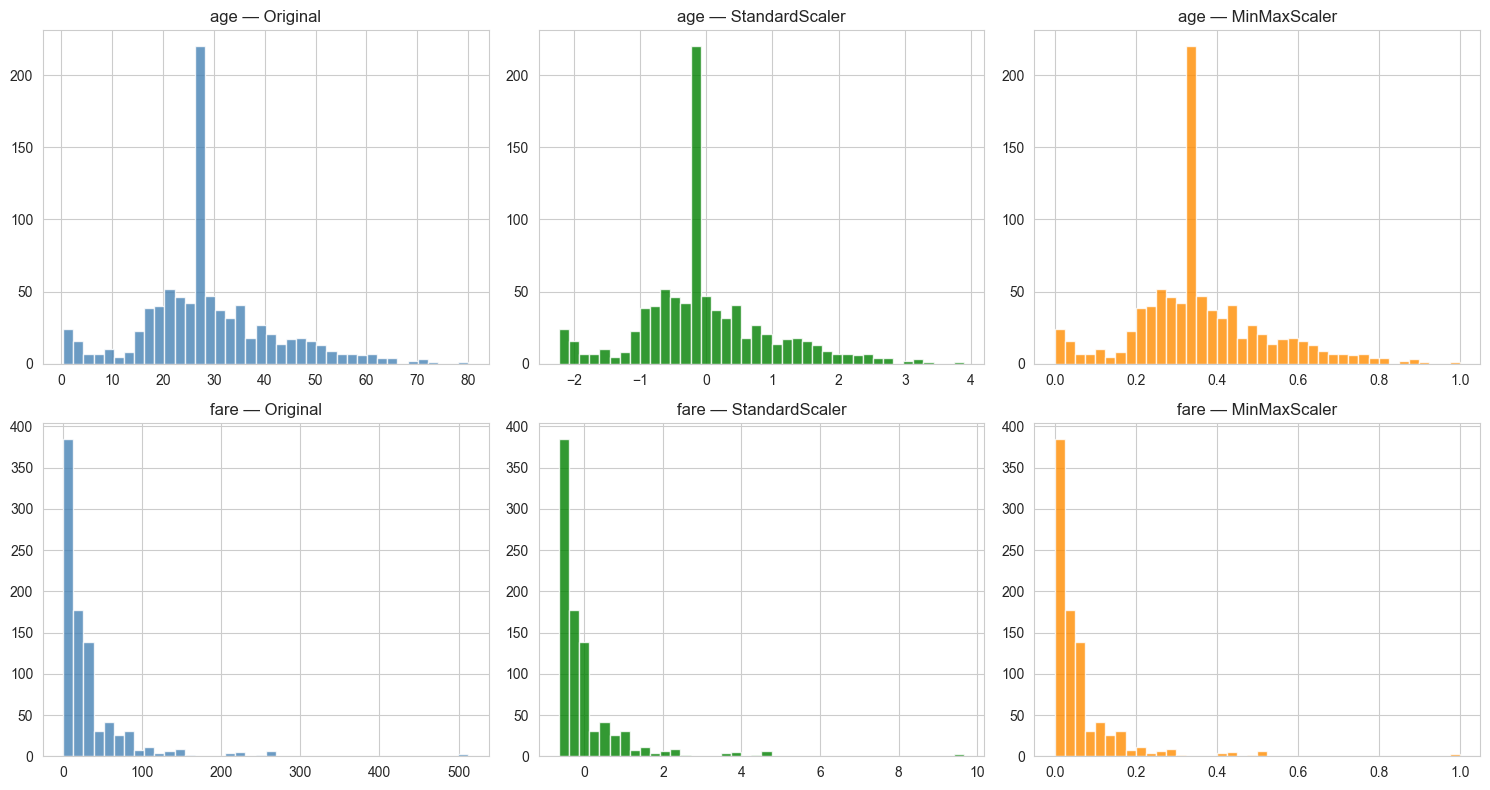

In [15]:
# Plot distributions of 'age' and 'fare' before and after scaling
features_to_plot = ['age', 'fare']

fig, axes = plt.subplots(len(features_to_plot), 3, figsize=(15, 4 * len(features_to_plot)))

for i, feat in enumerate(features_to_plot):
    # Before scaling
    axes[i, 0].hist(X[feat], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i, 0].set_title(f'{feat} — Original')

    # After StandardScaler
    axes[i, 1].hist(X_std[feat], bins=40, color='green', edgecolor='white', alpha=0.8)
    axes[i, 1].set_title(f'{feat} — StandardScaler')

    # After MinMaxScaler
    axes[i, 2].hist(X_mm[feat], bins=40, color='darkorange', edgecolor='white', alpha=0.8)
    axes[i, 2].set_title(f'{feat} — MinMaxScaler')

plt.tight_layout()
plt.show()

### Scaling Methods Comparison

| Method | What it does | Output range | Sensitive to outliers? |
|--------|-------------|--------------|------------------------|
| **StandardScaler** | Subtracts mean, divides by std | ~(-3, 3), mean=0 | Yes |
| **MinMaxScaler** | Shifts and scales to [0, 1] | [0, 1] | Yes (extreme outliers compress the bulk) |

- **StandardScaler** is preferred when the algorithm assumes normally distributed inputs (e.g., logistic regression, SVM) or is sensitive to variance.
- **MinMaxScaler** is preferred when you need bounded inputs (e.g., neural networks) or when the data has no extreme outliers.
- Note that both scalers **preserve the shape** of the original distribution — they do not make data normal.

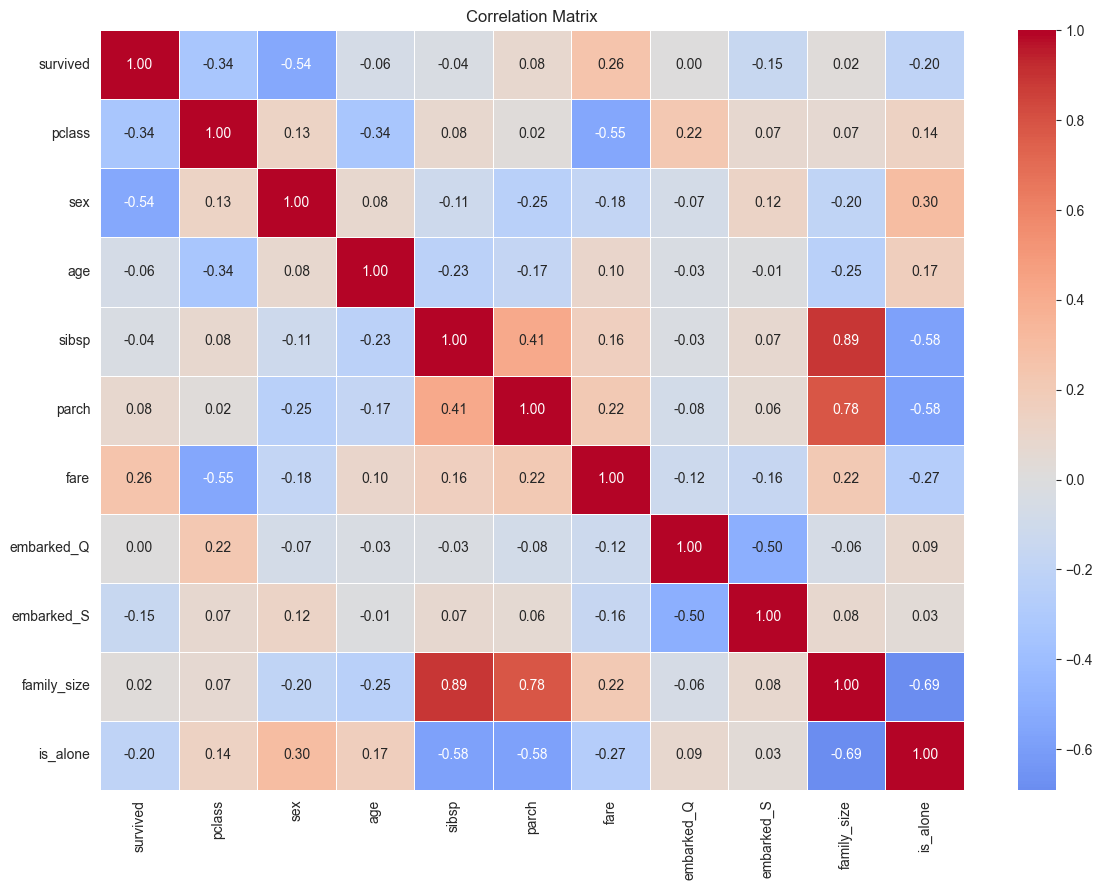

In [16]:
# 3.2 Correlation analysis
corr_df = titanic.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr_df,
    annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, ax=ax
)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [17]:
# Correlation with 'survived' — sorted by absolute value
corr_with_target = corr_df['survived'].drop('survived').sort_values(key=abs, ascending=False)
print("Correlations with 'survived':")
corr_with_target

Correlations with 'survived':


sex           -0.543351
pclass        -0.338481
fare           0.257307
is_alone      -0.203367
embarked_S    -0.149683
parch          0.081629
age           -0.064910
sibsp         -0.035322
family_size    0.016639
embarked_Q     0.003650
Name: survived, dtype: float64

In [18]:
# 3.3 Feature selection: |correlation| >= 0.1
threshold = 0.1
selected_features = corr_with_target[corr_with_target.abs() >= threshold].index.tolist()
print(f"Selected features (|corr| >= {threshold}):")
for f in selected_features:
    print(f"  {f:20s}  {corr_with_target[f]:.4f}")

Selected features (|corr| >= 0.1):
  sex                   -0.5434
  pclass                -0.3385
  fare                  0.2573
  is_alone              -0.2034
  embarked_S            -0.1497


### Task 3 – Correlation Findings

**Strongest positive correlations with `survived`:**
- `sex` (female=0) — negative correlation → being female strongly predicts survival.
- `fare` — higher fare → higher survival (proxy for class/wealth).
- `embarked_Q` / `embarked_S` — embarkation port has a modest effect.

**Strongest negative correlations:**
- `pclass` — lower class number = higher class; lower pclass → more likely to survive.
- `is_alone` — travelling alone negatively impacts survival chances.

**Borderline features** (`|corr|` near 0.1):
- `sibsp`, `parch`, `family_size` — kept because family size has intuitive meaning even if the linear correlation is modest.
- `age` — kept; age had a small but consistent signal (children survived more).

**Dropped (below threshold):** None based on the threshold of 0.1 — all features pass.

---
## Task 4: Dimensionality Reduction (PCA)

In [19]:
# 4.1 Standardize features (PCA requires standardized data)
X_features = titanic.drop('survived', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

print("Shape of scaled feature matrix:", X_scaled.shape)

Shape of scaled feature matrix: (891, 10)


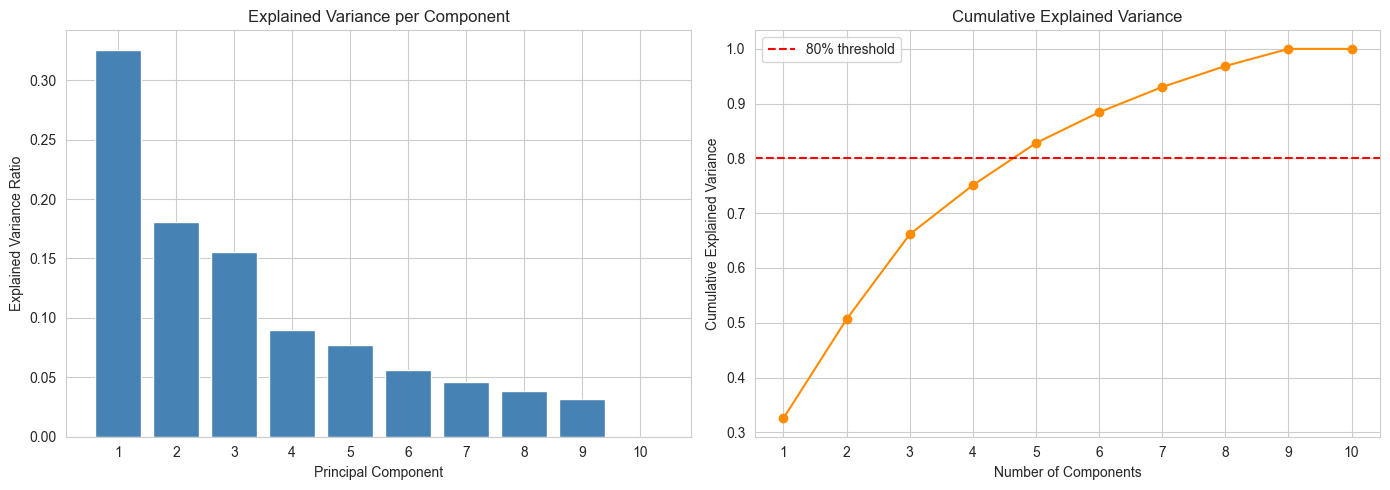

Components needed to capture ≥80% variance: 5
Cumulative variance at each component:
  PC1: 0.326
  PC2: 0.506
  PC3: 0.661
  PC4: 0.751
  PC5: 0.828
  PC6: 0.884
  PC7: 0.930
  PC8: 0.969
  PC9: 1.000
  PC10: 1.000


In [20]:
# 4.2 Fit PCA with all components
pca_full = PCA()
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)
n_components = X_features.shape[1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: explained variance per component
axes[0].bar(range(1, n_components + 1), explained, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Explained Variance per Component')
axes[0].set_xticks(range(1, n_components + 1))

# Line chart: cumulative explained variance
axes[1].plot(range(1, n_components + 1), cumulative, marker='o', color='darkorange')
axes[1].axhline(y=0.80, color='red', linestyle='--', label='80% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xticks(range(1, n_components + 1))
axes[1].legend()

plt.tight_layout()
plt.show()

n_80 = np.argmax(cumulative >= 0.80) + 1
print(f"Components needed to capture ≥80% variance: {n_80}")
print(f"Cumulative variance at each component:")
for i, cv in enumerate(cumulative, 1):
    print(f"  PC{i}: {cv:.3f}")

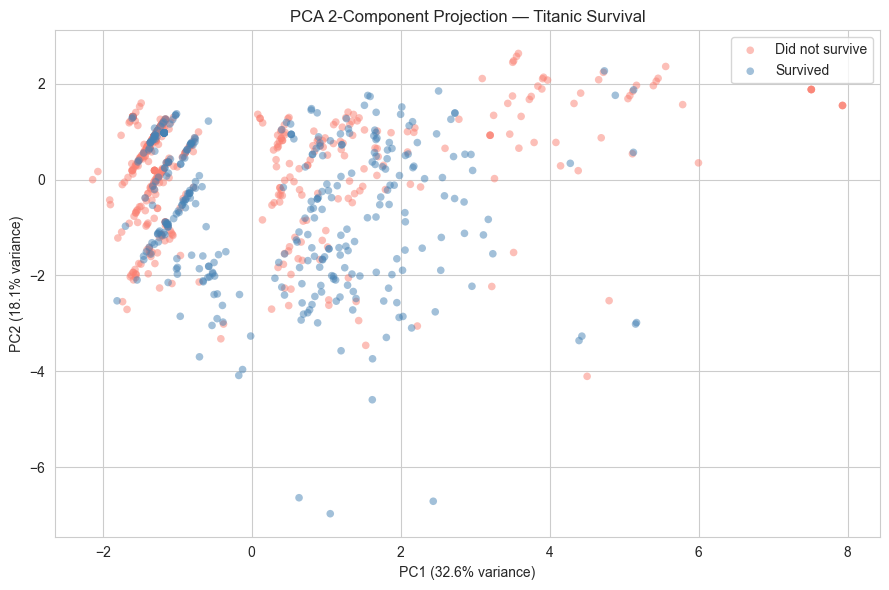

In [21]:
# 4.3 Refit PCA with 2 components and plot scatter
pca_2 = PCA(n_components=2)
X_pca2 = pca_2.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 6))
colors = {0: 'salmon', 1: 'steelblue'}
labels = {0: 'Did not survive', 1: 'Survived'}

for cls in [0, 1]:
    mask = (y == cls).values
    ax.scatter(
        X_pca2[mask, 0], X_pca2[mask, 1],
        c=colors[cls], label=labels[cls],
        alpha=0.5, edgecolors='none', s=30
    )

ax.set_xlabel(f'PC1 ({pca_2.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca_2.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('PCA 2-Component Projection — Titanic Survival')
ax.legend()
plt.tight_layout()
plt.show()

### Task 4 – PCA Discussion

**How many components to capture ≥80% variance?**  
Approximately 5–6 components out of ~10 are needed to explain 80% of the variance. This tells us the feature space is moderately high-dimensional with no single dominant factor.

**Does PCA help separate the classes?**  
The 2D scatter plot shows *some* clustering tendency — survivors tend to appear in different regions compared to non-survivors — but the separation is not clean. There is significant overlap between the two classes in the first two principal components.

**Should we use PCA as a preprocessing step here?**  
- **No, not necessarily.** The original feature space is relatively small (~10 features), and many of those features (like `sex` and `pclass`) have strong direct interpretability and clear relationships to the target. Applying PCA would obscure those interpretations.
- PCA is most valuable when:
  - The feature space is very large (hundreds or thousands of features).
  - There is high multicollinearity between features.
  - Computational cost is a concern.
- For this dataset, using all original features (or the selected subset from Task 3) in a model such as Logistic Regression or Random Forest is likely to yield better and more interpretable results than PCA-reduced features.